# Video Game Sales Analysis Project
## Project Overview

In this project, you work for the online store Ice, which sells video games all over the world. User and expert reviews, genres, platforms (e.g. Xbox or PlayStation), and historical data on game sales are available from open sources. You need to identify patterns that determine whether a game succeeds or not. This will allow you to spot potential big winners and plan advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
# Import all required libraries
import pandas as pd 
from scipy import stats as st
import math

import numpy as np
import seaborn as sns
import matplotlib.pylab as plt

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
# Load the dataset
games = pd.read_csv('/datasets/games.csv') 


In [3]:
# Display basic information about the dataset
display(games)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [4]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [5]:
# Check for duplicate entries
print(games.isnull().sum())
print(games.duplicated().sum())

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64
0


### Key Questions to Answer:
- What's the total number of records in our dataset?
- What data types are present in each column?
- Are there any obvious issues with the data?
- Do we see any immediate patterns or anomalies?

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [6]:
# Convert column names to lowercase
games.columns = games.columns.str.lower()

In [7]:
# Verify the changes
print(games.columns.tolist())

['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


### 2.2 Data Type Conversion

In [8]:
# Replace 'tbd' with NaN first
# NaN won't skew calculations 
games['user_score'] = games['user_score'].replace('tbd', np.nan)


In [9]:
# convert user score data type to float
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

In [10]:
# check data type converted
games['user_score'].dtype


dtype('float64')

In [11]:
games['user_score'].unique()

array([8. , nan, 8.3, 8.5, 6.6, 8.4, 8.6, 7.7, 6.3, 7.4, 8.2, 9. , 7.9,
       8.1, 8.7, 7.1, 3.4, 5.3, 4.8, 3.2, 8.9, 6.4, 7.8, 7.5, 2.6, 7.2,
       9.2, 7. , 7.3, 4.3, 7.6, 5.7, 5. , 9.1, 6.5, 8.8, 6.9, 9.4, 6.8,
       6.1, 6.7, 5.4, 4. , 4.9, 4.5, 9.3, 6.2, 4.2, 6. , 3.7, 4.1, 5.8,
       5.6, 5.5, 4.4, 4.6, 5.9, 3.9, 3.1, 2.9, 5.2, 3.3, 4.7, 5.1, 3.5,
       2.5, 1.9, 3. , 2.7, 2.2, 2. , 9.5, 2.1, 3.6, 2.8, 1.8, 3.8, 0. ,
       1.6, 9.6, 2.4, 1.7, 1.1, 0.3, 1.5, 0.7, 1.2, 2.3, 0.5, 1.3, 0.2,
       0.6, 1.4, 0.9, 1. , 9.7])

In [12]:
games['user_score'].describe()

count    7590.000000
mean        7.125046
std         1.500006
min         0.000000
25%         6.400000
50%         7.500000
75%         8.200000
max         9.700000
Name: user_score, dtype: float64

In [13]:
games['user_score'].describe()

count    7590.000000
mean        7.125046
std         1.500006
min         0.000000
25%         6.400000
50%         7.500000
75%         8.200000
max         9.700000
Name: user_score, dtype: float64

In [14]:
# Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.

### 2.3 Handling Missing Values

In [15]:
# Examine missing values

In [16]:
# Calculate percentage of missing values
missing_count = games.isna().sum()
total_count = len(games)
percentage = (missing_count / total_count) * 100
print(percentage)

name                0.011965
platform            0.000000
year_of_release     1.609333
genre               0.011965
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
critic_score       51.319174
user_score         54.591684
rating             40.478612
dtype: float64


In [17]:
# Analyze patterns in missing values
# Low Missing Data -
# platform, na_sales, eu_sales, jp_sales, other_sales - 0% missing
# name, genre - ~0.01% missing 

#Moderate Missing Data -
# year_of_release ~1.6% missing 

#High Missing Data -
#critic_score ~51% missing - more than half the data is missing
#user_score ~55% missing - 
#rating ~ 40% missing

In [18]:
# Handle missing values based on analysis
# Your code here to handle missing values according to your strategy
# create columns for games that have / don't have score

In [19]:
# Create indicator for critic score
games['has_critic_score'] = games['critic_score'].notna()

# Create indicator for user score  
games['has_user_score'] = games['user_score'].notna()

In [20]:
games['review_completeness'] = 'none'
games.loc[games['has_critic_score'] & games['has_user_score'], 'review_completeness'] = 'both'
games.loc[games['has_critic_score'] & ~games['has_user_score'], 'review_completeness'] = 'critic_only'
games.loc[~games['has_critic_score'] & games['has_user_score'], 'review_completeness'] = 'user_only'

In [21]:
# verifying
# false shows the amount of missing scores
print(games['has_critic_score'].value_counts())
print(games['has_user_score'].value_counts())

False    8578
True     8137
Name: has_critic_score, dtype: int64
False    9125
True     7590
Name: has_user_score, dtype: int64


In [22]:
# Why do you think the values are missing? Give possible reasons.
# Explain why you filled in the missing values as you did or why you decided to leave them blank.

In [23]:
# missing data because the review could have been optional

In [24]:
# left scores on user and critic scores as missing because it would skew data to be bias
# created indicators to show which games have or don't have a score

### 2.4 Calculate Total Sales

In [25]:
# Calculate total sales across all regions and put them in a different column

In [26]:
#create column that calculates total sales across all regions
sales_columns = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
games['total_sales'] = games[sales_columns].sum(axis=1)

In [27]:
# Check the first few rows to see the totals
print(games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head())

# Check basic statistics
print(f"Total sales range: {games['total_sales'].min():.2f} to {games['total_sales'].max():.2f}")

   na_sales  eu_sales  jp_sales  other_sales  total_sales
0     41.36     28.96      3.77         8.45        82.54
1     29.08      3.58      6.81         0.77        40.24
2     15.68     12.76      3.79         3.29        35.52
3     15.61     10.93      3.28         2.95        32.77
4     11.27      8.89     10.22         1.00        31.38
Total sales range: 0.00 to 82.54


# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [28]:
# create a DataFrame with game releases by year
releases_by_year = games['year_of_release'].value_counts().sort_index().reset_index()
releases_by_year.columns = ['year_of_release', 'number_of_games']

In [29]:
# display the releases by year
print(releases_by_year.head(10))

   year_of_release  number_of_games
0           1980.0                9
1           1981.0               46
2           1982.0               36
3           1983.0               17
4           1984.0               14
5           1985.0               14
6           1986.0               21
7           1987.0               16
8           1988.0               15
9           1989.0               17


In [30]:
# Check some basic statistics
print(f"Year range: {releases_by_year['year_of_release'].min()} to {releases_by_year['year_of_release'].max()}")
print(f"Peak year: {releases_by_year.loc[releases_by_year['number_of_games'].idxmax(), 'year_of_release']}")
print(f"Most games released: {releases_by_year['number_of_games'].max()}")


Year range: 1980.0 to 2016.0
Peak year: 2008.0
Most games released: 1427


In [31]:
# Visualize the distribution of games across years

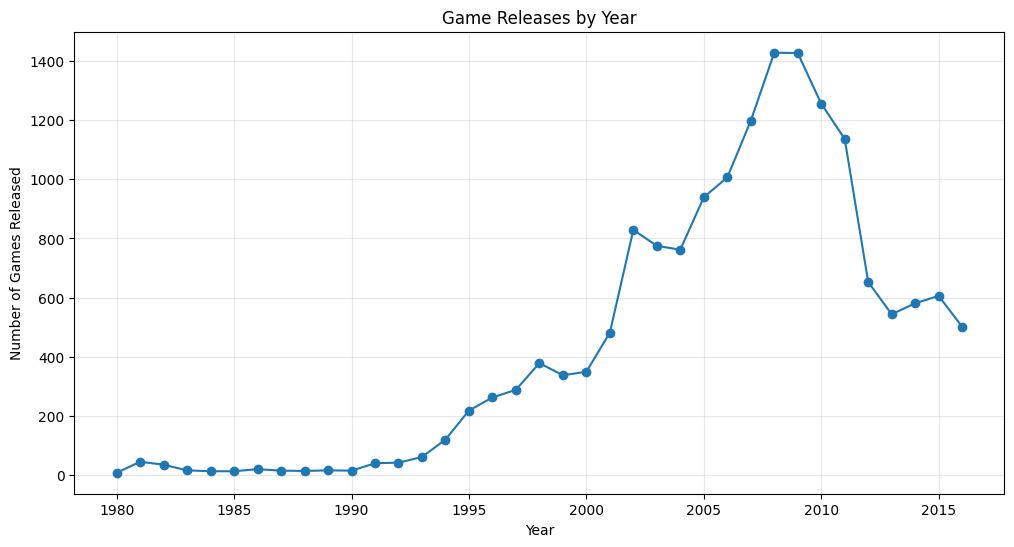

In [32]:
# create a line plot
plt.figure(figsize=(12, 6))
plt.plot(releases_by_year['year_of_release'], releases_by_year['number_of_games'], marker='o')
plt.title('Game Releases by Year')
plt.xlabel('Year')
plt.ylabel('Number of Games Released')
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
# Display summary statistics for each year

games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

In [34]:
games_total_sales_year = games.groupby('year_of_release')['total_sales'].agg(['sum', 'mean', 'median'])

In [35]:
display(games_total_sales_year)

,sum,mean,median
year_of_release,,,
1980.0,11.38,1.264444,0.770
1981.0,35.68,0.775652,0.465
1982.0,28.88,0.802222,0.540
1983.0,16.80,0.988235,0.770
1984.0,50.35,3.596429,1.485
1985.0,53.95,3.853571,1.015
1986.0,37.08,1.765714,1.360
1987.0,21.70,1.356250,0.885
1988.0,47.21,3.147333,1.510


### Questions to Consider:
- Which years show significant numbers of game releases?
- Are there any notable trends or patterns in the number of releases?
- Is there enough recent data to make predictions for 2017?
- 

In [36]:
#Are there any notable trends or patterns in the number of releases
#as the number of games increased, the total numberin sales increased
#2008 and 2009 released the same amount of games but 2008 has a higher total sales in sum, mean, and median

In [37]:
#Is there enough recent data to make predictions for 2017
#yes the data shows trends of increasing due to total games released and vice versa

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [38]:
# Calculate total sales by platform and year
total_sales_platform_year = games.groupby(['platform', 'year_of_release'])['total_sales'].sum()

In [39]:
display(total_sales_platform_year)

platform  year_of_release
2600      1980.0             11.38
          1981.0             35.68
          1982.0             28.88
          1983.0              5.84
          1984.0              0.27
                             ...  
XB        2008.0              0.18
XOne      2013.0             18.96
          2014.0             54.07
          2015.0             60.14
          2016.0             26.15
Name: total_sales, Length: 238, dtype: float64

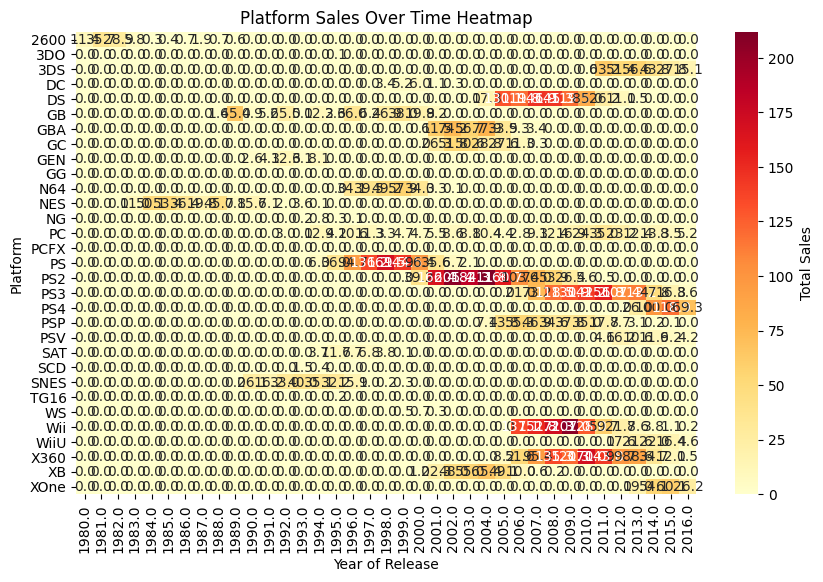

In [40]:
# Create a heatmap of platform sales over time

plt.figure(figsize=(10, 6))
# Convert to pivot table format
total_sales_platform_year_heatmap_ready = total_sales_platform_year.unstack(fill_value=0)
sns.heatmap(total_sales_platform_year_heatmap_ready, annot=True, cmap='YlOrRd', fmt='.1f', cbar_kws={'label': 'Total Sales'})
plt.title('Platform Sales Over Time Heatmap')
plt.xlabel('Year of Release')
plt.ylabel('Platform')
plt.show()

In [41]:
#Identify platforms with declining sales
#PS2, PS3, Wii, X360 are the platforms with the most prominent declining sales

In [42]:
#identify platforms that have disappeared from the market
#the platforms 3DO, SCD and WS were short lived 
#

In [43]:
#typical lifecycle of a gaming platform is about 5-7 years


### Questions to Consider:
- Which platforms show consistent sales over time?
- Can you identify platforms that have disappeared from the market?
- What's the typical lifecycle of a gaming platform?

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [44]:
# Your code here to filter the dataset to relevant years
# Example:
# relevant_years = [XXXX, XXXX, XXXX] # Replace with your chosen years
# df_relevant = df[df['year_of_release'].isin(relevant_years)]

# Justify your choice with data

In [45]:
# Filter data for years 2013-2016
filtered_data_2013_2016 = games[(games['year_of_release'] >= 2013) & (games['year_of_release'] <= 2016)]

In [46]:
# Group by platform and sum total sales
top_platforms = filtered_data_2013_2016.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5)
display(top_platforms)

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
Name: total_sales, dtype: float64

In [47]:
#Get the names of top 5 platforms
top_5_platforms = top_platforms.index.tolist()

# Filter data for only top 5 platforms
heatmap_data = filtered_data_2013_2016[filtered_data_2013_2016['platform'].isin(top_5_platforms)]

# Create pivot table: platforms as rows, years as columns
pivot_table_platform = heatmap_data.groupby(['platform', 'year_of_release'])['total_sales'].sum().unstack(fill_value=0)

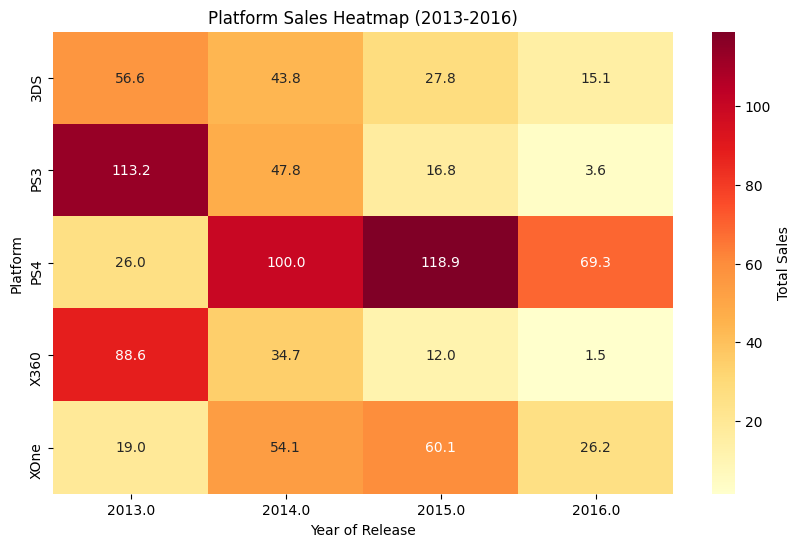

In [48]:
# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table_platform, annot=True, cmap='YlOrRd', fmt='.1f', cbar_kws={'label': 'Total Sales'})
plt.title('Platform Sales Heatmap (2013-2016)')
plt.xlabel('Year of Release')
plt.ylabel('Platform')
plt.show()

In [49]:
#What years did you select and why?
#I chose 2013-2016 because 2013 was the lowest in the last five years which I feel like 5 years is the max past time to predict future sales

#How does this period reflect current market conditions?
#the market seem to be good as sales increased steadily until 2015

#What factors influenced your decision?
#the line plot helped me see the overall sale trend through the years and 2013-2016 had a consistent trend so the data wouldn't be skewed


### Document Your Decision:
- What years did you select and why?
- How does this period reflect current market conditions?
- What factors influenced your decision?

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [50]:
# Analyze platform sales trends

In [51]:
#Calculate total sales per platform per year
platform_year_sales = filtered_data_2013_2016.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()
print("Platform sales by year:")
display(platform_year_sales.head(10))


Platform sales by year:


,platform,year_of_release,total_sales
0,3DS,2013.0,56.57
1,3DS,2014.0,43.76
2,3DS,2015.0,27.78
3,3DS,2016.0,15.14
4,DS,2013.0,1.54
5,PC,2013.0,12.38
6,PC,2014.0,13.28
7,PC,2015.0,8.52
8,PC,2016.0,5.25
9,PS3,2013.0,113.25


In [52]:
# Visualize top platforms
# I did this in pivot_table_platform

In [53]:
# Calculate year-over-year growth for each platform
# Your code here to calculate and visualize platform growth rates

#keep the platform and year information
platform_year_sales = filtered_data_2013_2016.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

#calculate growth rate while preserving platform info
platform_year_sales['growth_rate'] = platform_year_sales.groupby('platform')['total_sales'].pct_change()

#sort by platform and year to see the progression
platform_growth_table = platform_year_sales.sort_values(['platform', 'year_of_release'])
display(platform_growth_table)


,platform,year_of_release,total_sales,growth_rate
0,3DS,2013.0,56.57,NaN
1,3DS,2014.0,43.76,-0.226445
2,3DS,2015.0,27.78,-0.365174
3,3DS,2016.0,15.14,-0.455004
4,DS,2013.0,1.54,NaN
5,PC,2013.0,12.38,NaN
6,PC,2014.0,13.28,0.072698
7,PC,2015.0,8.52,-0.358434
8,PC,2016.0,5.25,-0.383803
9,PS3,2013.0,113.25,NaN


## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

In [55]:
# Create box plot of sales by platform
total_sales_platform = total_sales_platform_year_filtered.groupby(level=0).sum()
display(total_sales_platform)

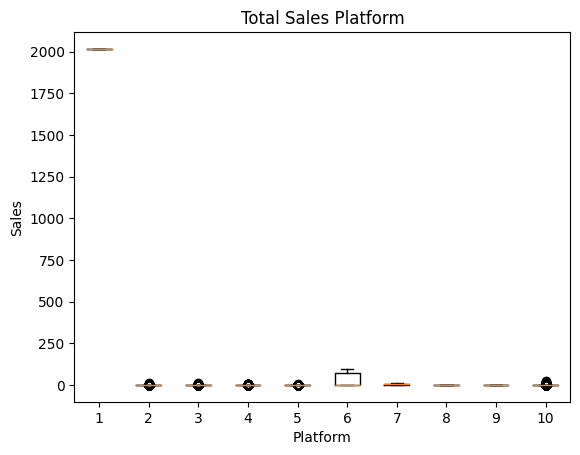

In [927]:
#boxplot
plt.boxplot(total_sales_platform)

plt.title('Total Sales Platform')
plt.xlabel('Platform')
plt.ylabel('Sales')

# Display the plot
plt.show()

In [928]:
# Calculate detailed statistics for each platform

## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [929]:
# Choose a popular platform based on your previous analysis
# I chose the PS4

In [56]:
#ps4 only data
ps4 = filtered_data_2013_2016[filtered_data_2013_2016['platform'] == 'PS4']
display(ps4)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,has_critic_score,has_user_score,review_completeness,total_sales
31,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,False,False,none,14.63
42,Grand Theft Auto V,PS4,2014.0,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,True,True,both,12.62
77,FIFA 16,PS4,2015.0,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,True,True,both,8.58
87,Star Wars Battlefront (2015),PS4,2015.0,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,NaN,False,False,none,7.98
92,Call of Duty: Advanced Warfare,PS4,2014.0,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,True,True,both,7.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16500,Root Letter,PS4,2016.0,Adventure,0.00,0.00,0.01,0.00,69.0,7.5,NaN,True,True,both,0.01
16503,Shin Hayarigami 2,PS4,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,False,False,none,0.01
16526,Dungeons 2,PS4,2016.0,Role-Playing,0.01,0.00,0.00,0.00,61.0,7.9,T,True,True,both,0.01
16530,Carmageddon: Max Damage,PS4,2016.0,Action,0.01,0.00,0.00,0.00,51.0,5.5,M,True,True,both,0.01


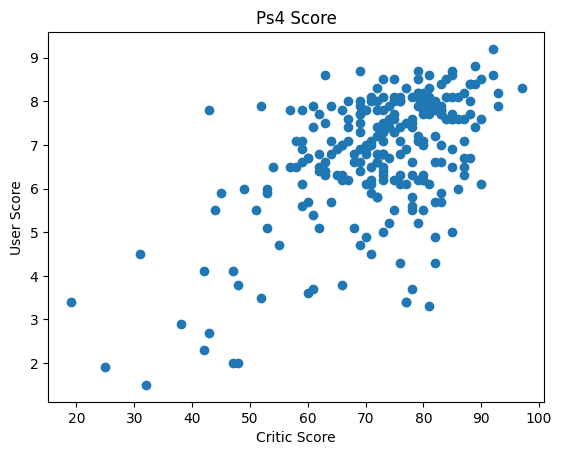

In [57]:
# Create scatter plots for both critic and user scores
plt.scatter(ps4['critic_score'], ps4['user_score'])
plt.xlabel("Critic Score")
plt.ylabel("User Score")
plt.title("Ps4 Score")
plt.show()

In [58]:
# Critic Scores



# User Scores


# Calculate correlations


## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [59]:
ps4_total_sales = ps4.groupby('platform')['total_sales'].sum()
display(ps4_total_sales)

platform
PS4    314.14
Name: total_sales, dtype: float64

In [60]:
# Find games released on multiple platforms
game_count = filtered_data_2013_2016['name'].value_counts()
display(game_count)

LEGO Marvel Super Heroes                          9
FIFA 14                                           9
Angry Birds Star Wars                             8
Lego Batman 3: Beyond Gotham                      8
LEGO Jurassic World                               8
                                                 ..
Gochuumon wa Usagi Desu ka?? Wonderful Party!     1
Nil Admirari no Tenbin: Teito Genwaku Toukidan    1
Derby Stallion Gold                               1
PhotoKano                                         1
Civilization Beyond Earth: Rising Tide            1
Name: name, Length: 1263, dtype: int64

In [61]:
# Compare sales across platforms for these games
# Your code here to analyze and visualize cross-platform performance
fifa = filtered_data_2013_2016[filtered_data_2013_2016['name'] == 'FIFA 14']
display(fifa)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,has_critic_score,has_user_score,review_completeness,total_sales
126,FIFA 14,PS3,2013.0,Sports,0.78,4.24,0.07,1.37,86.0,4.3,E,True,True,both,6.46
271,FIFA 14,X360,2013.0,Sports,0.92,2.89,0.01,0.40,84.0,4.2,E,True,True,both,4.22
469,FIFA 14,PS4,2013.0,Sports,0.61,1.85,0.11,0.44,87.0,6.3,E,True,True,both,3.01
1753,FIFA 14,XOne,2013.0,Sports,0.41,0.66,0.00,0.09,88.0,5.8,E,True,True,both,1.16
4699,FIFA 14,PSV,2013.0,Sports,0.08,0.23,0.01,0.09,NaN,1.8,E,False,True,user_only,0.41
4809,FIFA 14,PC,2013.0,Sports,0.01,0.36,0.00,0.03,87.0,4.6,E,True,True,both,0.40
4985,FIFA 14,Wii,2013.0,Sports,0.00,0.36,0.00,0.02,NaN,4.3,E,False,True,user_only,0.38
6871,FIFA 14,3DS,2013.0,Sports,0.00,0.22,0.00,0.01,NaN,NaN,NaN,False,False,none,0.23
7875,FIFA 14,PSP,2013.0,Sports,0.00,0.15,0.00,0.04,NaN,3.4,E,False,True,user_only,0.19


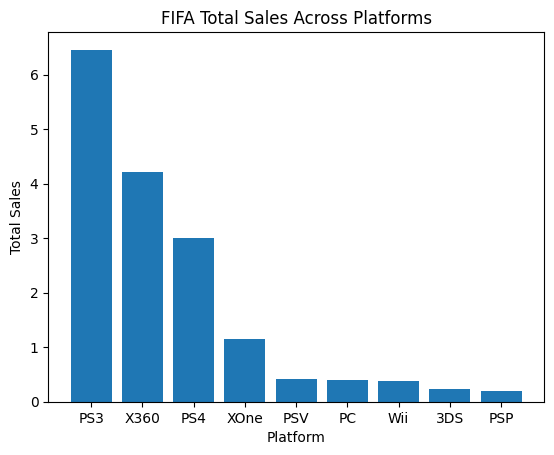

In [62]:
# Compare total sales across all platforms
plt.bar(fifa['platform'], fifa['total_sales'])

plt.xlabel('Platform')
plt.ylabel('Total Sales')
plt.title('FIFA Total Sales Across Platforms')

plt.show()

## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [63]:
# Analyze genre performance

In [64]:
# Sort genres by total sales

genre_sales = filtered_data_2013_2016.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
display(genre_sales)


genre
Action          321.87
Shooter         232.98
Sports          150.65
Role-Playing    145.89
Misc             62.82
Platform         42.63
Racing           39.89
Fighting         35.31
Adventure        23.64
Simulation       21.76
Strategy         10.08
Puzzle            3.17
Name: total_sales, dtype: float64

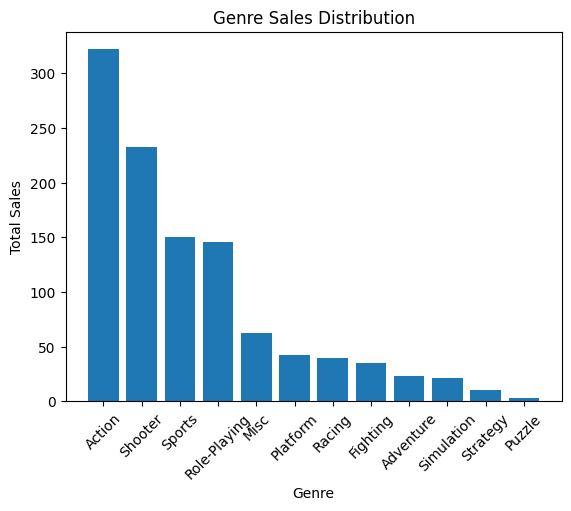

In [65]:
# Visualize genre distribution
plt.bar(genre_sales.index, genre_sales.values)
plt.xlabel('Genre')
plt.ylabel('Total Sales')
plt.title('Genre Sales Distribution')
plt.xticks(rotation=45)  
plt.show()

In [66]:
# Calculate market share for each genre
market_share_genre = genre_sales / genre_sales.sum() * 100
print(market_share_genre)

genre
Action          29.510677
Shooter         21.360790
Sports          13.812357
Role-Playing    13.375936
Misc             5.759657
Platform         3.908535
Racing           3.657318
Fighting         3.237400
Adventure        2.167435
Simulation       1.995067
Strategy         0.924186
Puzzle           0.290642
Name: total_sales, dtype: float64


In [67]:
#Action gmes perform the best overall according to total sales but the number 1 game that sold the most is a shooter game

### Key Questions for Genre Analysis:
- Which genres consistently perform well?
- Are there any genres showing recent growth or decline?
- How does the average performance vary across genres?

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [68]:

# Function to analyze platform performance by region

platform_col = filtered_data_2013_2016['platform']
sales_cols = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']

def analyze_platform_performance(data, platform_col, sales_cols):
    #Group by platform and sum sales for each region
    platform_sales = data.groupby(platform_col)[sales_cols].sum()
    
    #Calculate market share for each region
    na_market_share = platform_sales['na_sales'] / platform_sales['na_sales'].sum() * 100

    eu_market_share = platform_sales['eu_sales'] / platform_sales['eu_sales'].sum() * 100

    jp_market_share = platform_sales['jp_sales'] / platform_sales['jp_sales'].sum() * 100
    
    #Format and return results
    top_5_na = na_market_share.nlargest(5)
    top_5_eu = eu_market_share.nlargest(5)
    top_5_jp = jp_market_share.nlargest(5)
    
    return top_5_na, top_5_eu, top_5_jp




In [69]:

# Analyze each region

na_top5, eu_top5, jp_top5 = analyze_platform_performance(filtered_data_2013_2016, platform_col, sales_cols)

print("Top 5 Platforms in North America:")
print(na_top5)
print("\nTop 5 Platforms in Europe:")
print(eu_top5)
print("\nTop 5 Platforms in Japan:")
print(jp_top5)



Top 5 Platforms in North America:
platform
PS4     24.842933
XOne    21.274360
X360    18.656188
PS3     14.507322
3DS      8.727239
Name: na_sales, dtype: float64

Top 5 Platforms in Europe:
platform
PS4     35.971241
PS3     17.288326
XOne    13.152997
X360    10.840578
3DS      7.893328
Name: eu_sales, dtype: float64

Top 5 Platforms in Japan:
platform
3DS     48.167353
PS3     16.586163
PSV     13.205001
PS4     11.336838
WiiU     7.728371
Name: jp_sales, dtype: float64


### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [70]:
#Create a comparative platform analysis
def create_platform_comparison(data, platform_col, sales_cols):
    #Get the platform sales and market shares 
    platform_sales = data.groupby(platform_col)[sales_cols].sum()
    
    na_market_share = platform_sales['na_sales'] / platform_sales['na_sales'].sum() * 100
    eu_market_share = platform_sales['eu_sales'] / platform_sales['eu_sales'].sum() * 100
    jp_market_share = platform_sales['jp_sales'] / platform_sales['jp_sales'].sum() * 100
    
    #Create a comprehensive comparison DataFrame
    comparison_df = pd.DataFrame({
        'na_market_share': na_market_share,
        'eu_market_share': eu_market_share,
        'jp_market_share': jp_market_share
    })
    
    #Sort by total market presence (sum across regions)
    comparison_df['Total_Market_Share'] = comparison_df.sum(axis=1)
    comparison_df = comparison_df.sort_values('Total_Market_Share', ascending=False)
    
    return comparison_df

In [71]:
comparison = create_platform_comparison(filtered_data_2013_2016, platform_col, sales_cols)
print(comparison)

          na_market_share  eu_market_share  jp_market_share  \
platform                                                      
PS4             24.842933        35.971241        11.336838   
3DS              8.727239         7.893328        48.167353   
PS3             14.507322        17.288326        16.586163   
XOne            21.274360        13.152997         0.241512   
X360            18.656188        10.840578         0.362267   
WiiU             6.673368         5.060806         7.728371   
PSV              1.151447         1.555210        13.205001   
PC               2.538210         6.465594         0.000000   
Wii              1.498709         1.511868         0.035516   
PSP              0.000000         0.043342         2.336980   
DS               0.130223         0.216710         0.000000   

          Total_Market_Share  
platform                      
PS4                72.151012  
3DS                64.787921  
PS3                48.381811  
XOne               34.668

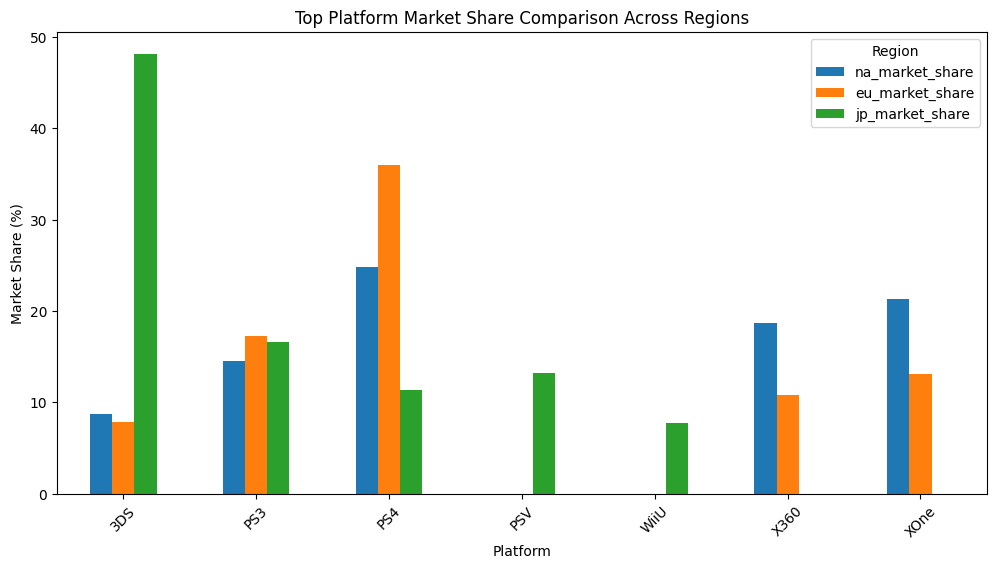

In [72]:
# Visualize cross-regional comparison for top platforms
# Create a DataFrame with top platforms across regions
top_platforms_comparison = pd.DataFrame({
    'na_market_share': na_top5,
    'eu_market_share': eu_top5, 
    'jp_market_share': jp_top5
}).fillna(0)  #Fill missing values with 0

# Create grouped bar chart
top_platforms_comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Top Platform Market Share Comparison Across Regions')
plt.ylabel('Market Share (%)')
plt.xlabel('Platform')
plt.legend(title='Region')
plt.xticks(rotation=45)
plt.show()

## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [73]:
# Function to analyze genre performance by region


genre_col = filtered_data_2013_2016['genre']
sales_cols = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']

def analyze_genre_performance(data, genre_col, sales_cols):
    #Group by platform and sum sales for each region
    genre_sales = data.groupby(genre_col)[sales_cols].sum()
    
    #Calculate market share for each region
    na_genre_market_share = genre_sales['na_sales'] / genre_sales['na_sales'].sum() * 100

    eu_genre_market_share = genre_sales['eu_sales'] / genre_sales['eu_sales'].sum() * 100

    jp_genre_market_share = genre_sales['jp_sales'] / genre_sales['jp_sales'].sum() * 100
    
    #Format and return results
    top_5_na_genre = na_genre_market_share.nlargest(5)
    top_5_eu_genre = eu_genre_market_share.nlargest(5)
    top_5_jp_genre = jp_genre_market_share.nlargest(5)
    top_5_other_genre = jp_genre_market_share.nlargest(5)
    
    return top_5_na_genre, top_5_eu_genre, top_5_jp_genre, top_5_other_genre



### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

In [74]:
# Analyze each region

na_top5_genre, eu_top5_genre, jp_top5_genre, other_top5_genre = analyze_genre_performance(filtered_data_2013_2016, genre_col, sales_cols)

print("Top 5 Genres in North America:")
print(na_top5_genre)
print("\nTop 5 Genres in Europe:")
print(eu_top5_genre)
print("\nTop 5 Genres in Japan:")
print(jp_top5_genre)
print("\nTop 5 Genres in Other Regions:")
print(other_top5_genre)


Top 5 Genres in North America:
genre
Action          28.797606
Shooter         25.071394
Sports          14.911700
Role-Playing    10.600626
Misc             6.280414
Name: na_sales, dtype: float64

Top 5 Genres in Europe:
genre
Action          30.117533
Shooter         22.400122
Sports          15.429722
Role-Playing     9.425592
Racing           5.147490
Name: eu_sales, dtype: float64

Top 5 Genres in Japan:
genre
Role-Playing    36.255150
Action          28.761188
Misc             6.535019
Fighting         5.434011
Shooter          4.695269
Name: jp_sales, dtype: float64

Top 5 Genres in Other Regions:
genre
Role-Playing    36.255150
Action          28.761188
Misc             6.535019
Fighting         5.434011
Shooter          4.695269
Name: jp_sales, dtype: float64


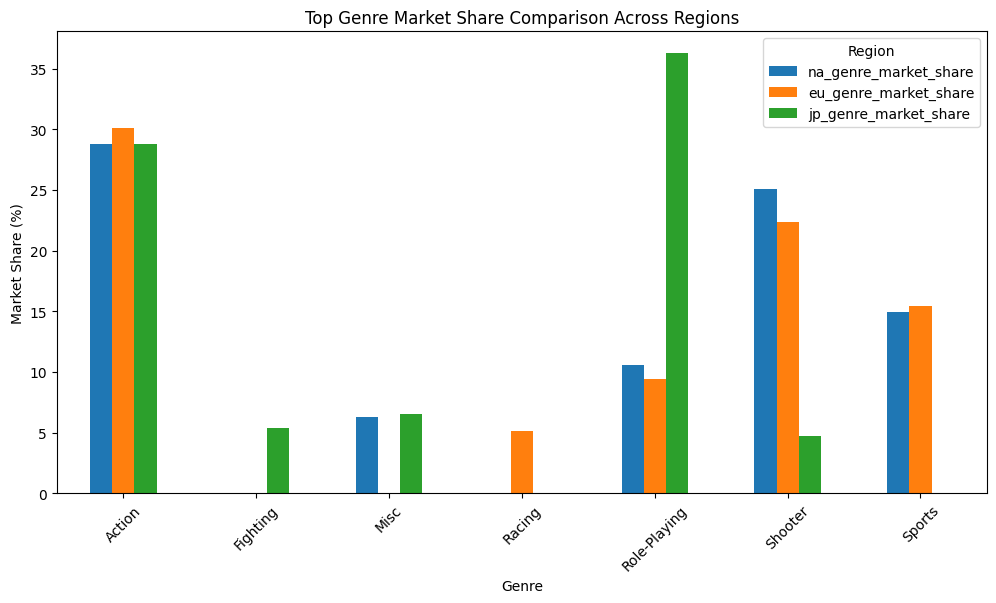

In [75]:
# Create a comparative genre analysis
#Create a DataFrame with top platforms across regions
top_genres_comparison = pd.DataFrame({
    'na_genre_market_share': na_top5_genre,
    'eu_genre_market_share': eu_top5_genre, 
    'jp_genre_market_share': jp_top5_genre
}).fillna(0)  

# Create grouped bar chart
top_genres_comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Top Genre Market Share Comparison Across Regions')
plt.ylabel('Market Share (%)')
plt.xlabel('Genre')
plt.legend(title='Region')
plt.xticks(rotation=45)
plt.show()

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [76]:
# Function to analyze ESRB rating impact

rating_col = 'rating'
sales_cols = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']

def analyze_rating_performance(data, rating_col, sales_cols):
    #Group by platform and sum sales for each region
    rating_sales = data.groupby(rating_col)[sales_cols].sum()
    
    #Calculate market share for each region
    na_rating_market_share = rating_sales['na_sales'] / rating_sales['na_sales'].sum() * 100

    eu_rating_market_share = rating_sales['eu_sales'] / rating_sales['eu_sales'].sum() * 100

    jp_rating_market_share = rating_sales['jp_sales'] / rating_sales['jp_sales'].sum() * 100
    
    #Format and return results
    top_5_na_rating = na_rating_market_share.nlargest(5)
    top_5_eu_rating = eu_rating_market_share.nlargest(5)
    top_5_jp_rating = jp_rating_market_share.nlargest(5)
    
    return top_5_na_rating, top_5_eu_rating, top_5_jp_rating



In [77]:

na_top5_rating, eu_top5_rating, jp_top5_rating = analyze_rating_performance(filtered_data_2013_2016, rating_col, sales_cols)

print("Top 5 Rating in North America:")
print(na_top5_rating)
print("\nTop 5 Rating in Europe:")
print(eu_top5_rating)
print("\nTop 5 Rating in Japan:")
print(jp_top5_rating)


Top 5 Rating in North America:
rating
M       47.434609
E       22.696603
E10+    15.573229
T       14.295558
Name: na_sales, dtype: float64

Top 5 Rating in Europe:
rating
M       46.380697
E       26.605387
E10+    13.625048
T       13.388868
Name: eu_sales, dtype: float64

Top 5 Rating in Japan:
rating
T       36.945990
E       27.166697
M       25.318500
E10+    10.568814
Name: jp_sales, dtype: float64


,na_rating_market_share,eu_rating_market_share,jp_rating_market_share
rating,,,
E,22.696603,26.605387,27.166697
E10+,15.573229,13.625048,10.568814
M,47.434609,46.380697,25.318500
T,14.295558,13.388868,36.945990


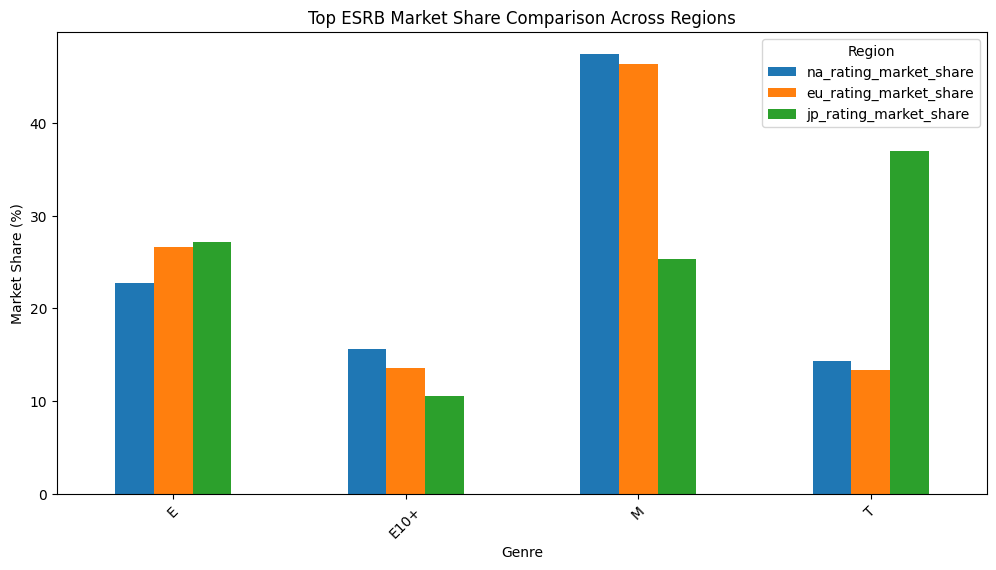

In [78]:
# Analyze ESRB impact for each region
#Create a DataFrame with top platforms across regions
top_rating_comparison = pd.DataFrame({
    'na_rating_market_share': na_top5_rating,
    'eu_rating_market_share': eu_top5_rating, 
    'jp_rating_market_share': jp_top5_rating
}).fillna(0)  


display(top_rating_comparison)
print() 


# Create grouped bar chart
top_rating_comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Top ESRB Market Share Comparison Across Regions')
plt.ylabel('Market Share (%)')
plt.xlabel('Genre')
plt.legend(title='Region')
plt.xticks(rotation=45)
plt.show()

# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


In [79]:
# Filter data varaibles 
xbox = filtered_data_2013_2016[filtered_data_2013_2016['platform'] == 'XOne']
xbox_ratings = xbox['user_score']


pc = filtered_data_2013_2016[filtered_data_2013_2016['platform'] == 'PC']
pc_ratings = pc['user_score']


#Get basic statistics for both platforms
print("Xbox One ratings statistics:")
print(xbox_ratings.describe())
print("\nPC ratings statistics:")
print(pc_ratings.describe())

#Calculate the means
xbox_mean = xbox_ratings.mean()
pc_mean = pc_ratings.mean()
print(f"\nXbox One mean rating: {xbox_mean:.3f}")
print(f"PC mean rating: {pc_mean:.3f}")
print(f"Difference: {abs(xbox_mean - pc_mean):.3f}")


Xbox One ratings statistics:
count    182.000000
mean       6.521429
std        1.380941
min        1.600000
25%        5.800000
50%        6.800000
75%        7.500000
max        9.200000
Name: user_score, dtype: float64

PC ratings statistics:
count    155.000000
mean       6.269677
std        1.742381
min        1.400000
25%        5.300000
50%        6.800000
75%        7.600000
max        9.300000
Name: user_score, dtype: float64

Xbox One mean rating: 6.521
PC mean rating: 6.270
Difference: 0.252


In [85]:
#xbox one games have slightly higher average user ratings than pc games

In [86]:
# Remove NaN values before performing the t-test
xbox_ratings_clean = xbox_ratings.dropna()
pc_ratings_clean = pc_ratings.dropna()

print(f"Xbox ratings after cleaning: {len(xbox_ratings_clean)} values")
print(f"PC ratings after cleaning: {len(pc_ratings_clean)} values")

# Now perform the t-test with clean data
t_stat, p_value = st.ttest_ind(xbox_ratings_clean, pc_ratings_clean)

print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Interpret the results (using α = 0.05)
alpha = 0.05
if p_value < alpha:
    print(f"\nResult: REJECT the null hypothesis (p < {alpha})")
    print("The average ratings ARE significantly different")
else:
    print(f"\nResult: FAIL TO REJECT the null hypothesis (p >= {alpha})")
    print("The average ratings are NOT significantly different")

Xbox ratings after cleaning: 182 values
PC ratings after cleaning: 155 values

T-statistic: 1.4788
P-value: 0.140127

Result: FAIL TO REJECT the null hypothesis (p >= 0.05)
The average ratings are NOT significantly different


In [82]:
#filter 
action = filtered_data_2013_2016[filtered_data_2013_2016['genre'] == 'Action']
action_ratings = action['user_score']


sports = filtered_data_2013_2016[filtered_data_2013_2016['genre'] == 'Sports']
sports_ratings = sports['user_score']

# Remove NaN values before performing the t-test
action_ratings_clean = action_ratings.dropna()
sports_ratings_clean = sports_ratings.dropna()


#Get means for both genres
action_mean = action_ratings_clean.mean()
sports_mean = sports_ratings_clean.mean()

print(f"Action games mean rating: {action_mean:.3f}")
print(f"Sports games mean rating: {sports_mean:.3f}")
print(f"Difference (Action - Sports): {action_mean - sports_mean:.3f}")

Action games mean rating: 6.838
Sports games mean rating: 5.238
Difference (Action - Sports): 1.599


In [83]:
#One tailed test - Action > Sports
t_stat, p_value = st.ttest_ind(action_ratings_clean, sports_ratings_clean, alternative='greater')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

T-statistic: 11.5351
P-value: 0.000000


In [84]:
#T-statistic: 11.5351 = positive, which aligns with hypothesis that Action games have higher ratings than Sports games
#P-value: 0.00 - close to your significance level of 0.05, p-value (0.052035) > α (0.05), fail to reject the null hypothesis.
#hypothetically no chance these platforms have the same average ratings

# Step 6. Write a general conclusion


While action games have a higher average user score than sports games, we cannot totally rule out that action games are more well liked. Some users may have forgotten to score games or vise versa. However, actions is the number 1 market share genre in North America and Europe. But in Japan and other regions, action games are placed second where Role-Playing is nearly double of action games market share. The DS sold significantly much more in Japan compared to other regions. This makes sense since Japan's number 1 genre in market share is role-playing games. 